# 03 - Advanced LSTM Models

**Goal**: Build LSTM neural network for hourly temperature forecasting

**Model**: LSTM (Long Short-Term Memory) with multiple layers

**Why LSTM?**
- Captures long-term dependencies
- Handles daily/weekly weather patterns
- Best for complex non-linear patterns

**Horizons**: 24h, 48h, 72h, 96h, 120h, 144h, 168h (1-7 days)

### Step 1: Setup & Load Data

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')

# Load Member 1 data
url = "https://raw.githubusercontent.com/aejae-da/weather-forecasting-project-gha/main/data/weather_temperature_hourly.csv"
df = pd.read_csv(url, parse_dates=['date'])
print(f"✅ Loaded data: {df.shape}")
print("Features available:", list(df.columns))
df.head()

✅ Loaded data: (8785, 11)
Features available: ['date', 'y', 'hour', 'dayofweek', 'month', 'quarter', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


,date,y,hour,dayofweek,month,quarter,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos
0,2020-01-01 00:00:00,0.578000,0,2,1,1,0,0.000000,1.000000,0.974928,-0.222521
1,2020-01-01 01:00:00,0.141667,1,2,1,1,0,0.258819,0.965926,0.974928,-0.222521
2,2020-01-01 02:00:00,-0.153333,2,2,1,1,0,0.500000,0.866025,0.974928,-0.222521
3,2020-01-01 03:00:00,-0.615000,3,2,1,1,0,0.707107,0.707107,0.974928,-0.222521
4,2020-01-01 04:00:00,-1.416667,4,2,1,1,0,0.866025,0.500000,0.974928,-0.222521


### Step 2: Prepare LSTM Data
**LSTM needs**:
- Sequence data (past 168 hour → predict next 24h)
- Scaled features (0-1 range)
- Train/validation/test split

In [13]:
# Use all temporal features from 01
feature_cols = ['hour', 'hour_sin', 'hour_cos', 'dayofweek', 'dow_sin', 'dow_cos',
                'month', 'quarter', 'is_weekend']
X = df[feature_cols].values
y = df['y'].values

# Scale features
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

print(f"✅ Features scaled: X={X_scaled.shape}, y={y_scaled.shape}")

✅ Features scaled: X=(8785, 9), y=(8785,)


### Step 3: Create Sequences

**Window**: Use past 168 hours (7 days) to predict next horizon

**Example**: hours 0-167 → predict hour 168

In [14]:
def create_sequences(X, y, time_steps=168):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

# Create sequences
time_steps = 168  # 7 days lookback
X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_steps)

print(f"✅ Sequences created: {X_seq.shape} → {y_seq.shape}")

# Train/val/test split (80/10/10)
split1 = int(0.8 * len(X_seq))
split2 = int(0.9 * len(X_seq))

X_train, y_train = X_seq[:split1], y_seq[:split1]
X_val, y_val = X_seq[split1:split2], y_seq[split1:split2]
X_test, y_test = X_seq[split2:], y_seq[split2:]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

✅ Sequences created: (8617, 168, 9) → (8617,)
Train: (6893, 168, 9), Val: (862, 168, 9), Test: (862, 168, 9)


### Step 4: Build LSTM Model

**Architecture**:
- 3 LSTM layers (128→64→32 units)
- Dropout to prevent overfitting
- Dense output lay

In [15]:
# Build LSTM model
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(time_steps, X_train.shape[2])),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 168, 128)       │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 168, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 168, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,025 (519.63 KB)

 Trainable params: 133,025 (519.63 KB)

 Non-trainable params: 0 (0.00 B)

### Step 5: Train LSTM
**Training**: 50 epochs with early stopping

**Monitor**: Validation loss

Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 71s 607ms/step - loss: 0.0580 - mae: 0.1829 - val_loss: 0.0377 - val_mae: 0.1631
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 80s 592ms/step - loss: 0.0230 - mae: 0.1219 - val_loss: 0.0254 - val_mae: 0.1328
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 64s 590ms/step - loss: 0.0196 - mae: 0.1117 - val_loss: 0.0238 - val_mae: 0.1267
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 64s 593ms/step - loss: 0.0172 - mae: 0.1056 - val_loss: 0.0224 - val_mae: 0.1258
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 64s 597ms/step - loss: 0.0171 - mae: 0.1050 - val_loss: 0.0237 - val_mae: 0.1274
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 64s 596ms/step - loss: 0.0164 - mae: 0.1027 - val_loss: 0.0241 - val_mae: 0.1275
Epoch 7/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 84s 612ms/step - loss: 0.0168 - mae: 0.1041 - val_loss: 0.0237 - val_mae: 0.1284
Epoch 8/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 64s 590ms/step - loss: 0.0158 - mae: 0.1009 - val_loss: 0.0241 - val_mae: 0.1276
Epoch 9/50
108/108 ━━━━━━━━━━━━━

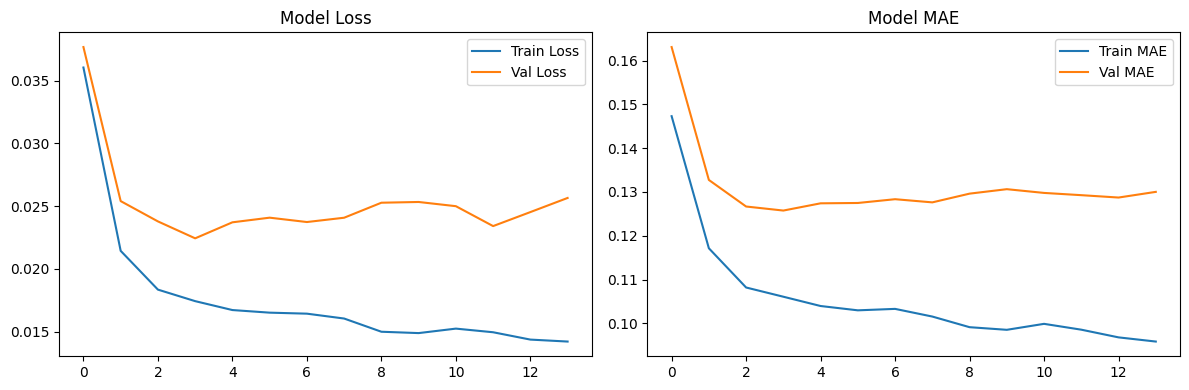

In [16]:
# Train with early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Model MAE')
plt.legend()
plt.tight_layout()
plt.show()

### Step 6: LSTM Forecasts (1-7 Days)
**Multi-step forecasting**: Use model predictions as new inputs


In [17]:
# Generate forecasts for 7 horizons
horizons = [24, 48, 72, 96, 120, 144, 168]
lstm_forecasts = {}
lstm_results = {}

for h in horizons:
    # Use last sequence from training data
    last_seq = X_test[0:1].copy()  # Shape: (1, 168, n_features)

    forecast = []
    current_input = last_seq.copy()

    # Multi-step forecast
    for _ in range(h):
        pred = model.predict(current_input, verbose=0)
        forecast.append(pred[0, 0])
        # Shift sequence
        current_input = np.roll(current_input, -1, axis=1)
        current_input[0, -1, 0] = pred[0, 0]  # Update target feature

    # Inverse scale
    forecast = scaler_y.inverse_transform(np.array(forecast).reshape(-1, 1)).flatten()
    actual = scaler_y.inverse_transform(y_test[:h].reshape(-1, 1)).flatten()

    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))

    lstm_forecasts[h] = forecast
    lstm_results[f'LSTM_h{h}'] = {'MAE': mae, 'RMSE': rmse}

    print(f"H{h}: MAE={mae:.3f}, RMSE={rmse:.3f}")

print("✅ LSTM forecasts complete")

H24: MAE=6.577, RMSE=6.768
H48: MAE=6.519, RMSE=6.711
H72: MAE=6.478, RMSE=6.629
H96: MAE=6.154, RMSE=6.300
H120: MAE=6.137, RMSE=6.266
H144: MAE=6.295, RMSE=6.417
H168: MAE=6.655, RMSE=6.840
✅ LSTM forecasts complete


### Step 7: Visualize LSTM vs Actual (48h)
**Comparison**: LSTM predictions vs real temperature

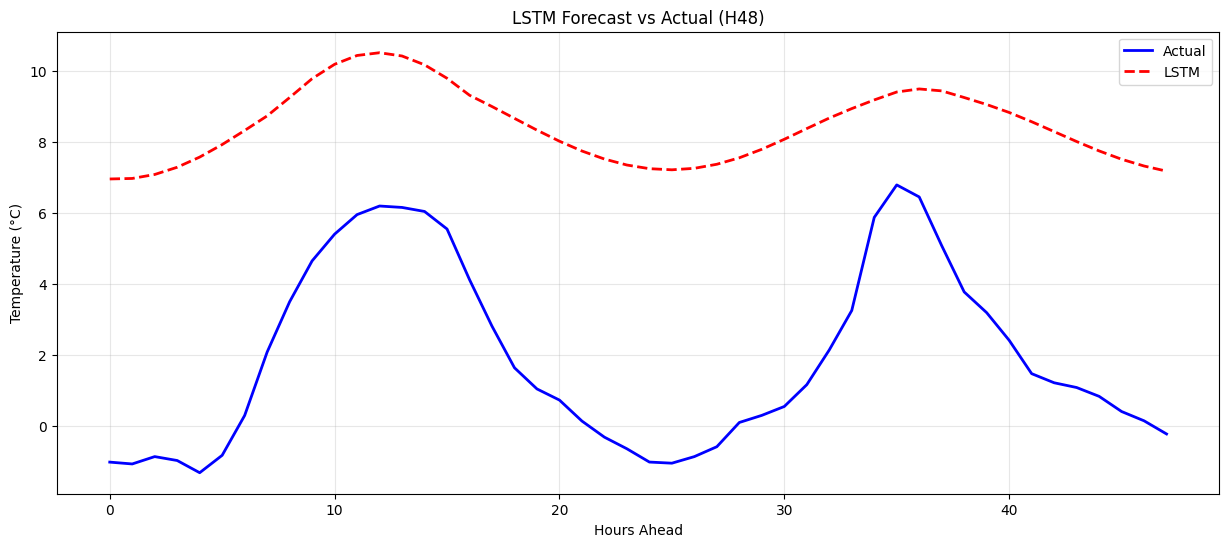

In [18]:
# Plot 48h forecast example
h_example = 48
plt.figure(figsize=(15, 6))
plt.plot(range(h_example), scaler_y.inverse_transform(y_test[:h_example].reshape(-1,1)).flatten(),
         'b-', label='Actual', linewidth=2)
plt.plot(range(h_example), lstm_forecasts[h_example], 'r--', label='LSTM', linewidth=2)
plt.title(f'LSTM Forecast vs Actual (H{h_example})')
plt.xlabel('Hours Ahead')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Step 8: Save Results
**Files created**:
- LSTM results table
- Raw LSTM forecasts (168h)

In [22]:
# Save LSTM results
lstm_results_df = pd.DataFrame(lstm_results).T.round(3)
lstm_results_df.to_csv('lstm_results.csv')
print("✅ Saved: lstm_results.csv")

# Save 168h forecasts
actual_168h = scaler_y.inverse_transform(y_test[:168].reshape(-1,1)).flatten()
lstm_168h = lstm_forecasts[168]

forecasts_df = pd.DataFrame({
    'step': range(168),
    'actual': actual_168h,
    'lstm': lstm_168h
})

forecasts_df.to_csv('lstm_forecasts_168h.csv', index=False)
print("✅ Saved: lstm_forecasts_168h.csv")
print(f"   • Shape: {forecasts_df.shape}")
print(forecasts_df.head())

from google.colab import files
files.download('lstm_results.csv')
files.download('lstm_forecasts_168h.csv')

✅ Saved: lstm_results.csv
✅ Saved: lstm_forecasts_168h.csv
   • Shape: (168, 3)
   step    actual      lstm
0     0 -1.015000  6.949000
1     1 -1.066667  6.963505
2     2 -0.860000  7.075133
3     3 -0.970000  7.278708
4     4 -1.313333  7.564613


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>